# Análisis exploratorio de datos (EDA)

In [25]:
# Importamos librerias a utilizar
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from scipy import stats
from scipy.fftpack import fft, fftfreq
from scipy.stats import zscore
import pingouin as pg 

In [2]:
# importamos datos
filename = 'C:/Users/luis_/Desktop\MaestriaEstadisticaAplicada/_7SeriesDeTiempo/Proyectos_python/datos_proyecto/datos_velocidad_viento.xlsx'
data = pd.read_excel(filename)

In [3]:
# Haciendo que el index sean las mismas fechas
data.index = data['FechaObservacion']

## 1. Introducción y contexto

Los datos utilizados en esta investigación se tomaron de la plataforma de datos abiertos de Colombia, los datos fueron suministrados a la plataforma por el Instituto de Hidrología, Meteorología y Estudios Ambientales (IDEAM). El conjunto de datos contiene la velocidad del viento (m/s), y la fecha y hora de realización de la medición. Los registros se realizaron cada 10 minutos desde junio 25 del 2012 hasta noviembre 22 del 2019, y fueron tomados en la ciudad de Bogotá, Colombia, para un total de 384 435 observaciones.

* Enlace de los datos: [Velocidad Viento](https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Velocidad-Viento/sgfv-3yp8/about_data)

**Objetivo:** El objetivo de este análisis es identificar patrones relevantes de la seria, tendencias, estacionalidad, valores atípicos, y otras características de la serie con el fin desarrollar un entendimiento de los datos antes de aplicar nuestro modelo predictivo,

## 2. Análisis preliminar

### 2.1. Inspección general

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 384435 entries, 2012-06-25 11:00:00 to 2019-11-22 19:20:00
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   FechaObservacion  384435 non-null  datetime64[ns]
 1   ValorObservado    384435 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.8 MB


### 2.2. Estádisticas descriptivas

In [5]:
# Estadística descriptiva
df_resumen = data['ValorObservado'].describe()
df_resumen['Skewness'] = data['ValorObservado'].skew()
df_resumen['Kurtosis'] = data['ValorObservado'].kurtosis()

print(df_resumen)

count       384435.000000
mean             1.923176
std              2.827910
min              0.000000
25%              1.000000
50%              1.500000
75%              2.200000
max             80.000000
Skewness        16.871123
Kurtosis       349.827977
Name: ValorObservado, dtype: float64


## 3. Visualización de la serie

### 3.1. Visualización temporal

In [6]:
# Creando tabla de fecha díaria y promedio diario de velocidad del viento
df_daily_avg = data.groupby(data['FechaObservacion'].dt.date)['ValorObservado'].mean().reset_index()

In [7]:
df_daily_avg.head()

,FechaObservacion,ValorObservado
0,2012-06-25,1.796154
1,2012-06-26,1.937500
2,2012-06-27,1.408333
3,2012-06-28,1.486806
4,2012-06-29,1.602778


Text(0, 0.5, 'velocidad del viento promedio por día')

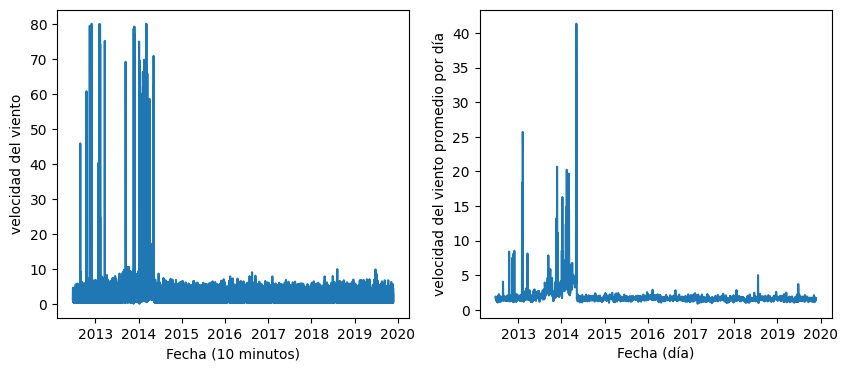

In [10]:
# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfica de línea 1, serie sin agrupar
axes[0].plot(data['FechaObservacion'], data['ValorObservado'])
axes[0].set_xlabel("Fecha (10 minutos)")
axes[0].set_ylabel("velocidad del viento")

# Gráfica de línea 2, serie agrupada por día
axes[1].plot(df_daily_avg['FechaObservacion'], df_daily_avg['ValorObservado'])
axes[1].set_xlabel("Fecha (día)")
axes[1].set_ylabel("velocidad del viento promedio por día")


(array([1.15894104e-01, 5.36212234e-01, 3.52865244e-01, 1.11654116e-01,
        6.28129593e-02, 3.60366512e-02, 1.66705685e-02, 7.06231222e-03,
        3.98962113e-03, 1.68754146e-03, 7.38096167e-04, 3.67422321e-04,
        1.56073198e-04, 6.82820243e-05, 3.90182996e-05, 7.80365992e-05,
        3.90182996e-05, 4.87728745e-05, 2.92637247e-05, 3.25152497e-05,
        2.27606748e-05, 4.22698245e-05, 2.92637247e-05, 2.60121997e-05,
        2.92637247e-05, 3.25152497e-05, 5.20243994e-05, 1.30060999e-05,
        2.92637247e-05, 6.50304993e-06, 2.60121997e-05, 3.57667746e-05,
        2.60121997e-05, 3.90182996e-05, 9.42942240e-05, 5.20243994e-05,
        4.55213495e-05, 6.17789743e-05, 4.22698245e-05, 3.57667746e-05,
        3.25152497e-05, 2.92637247e-05, 3.90182996e-05, 9.75457490e-06,
        6.50304993e-05, 4.22698245e-05, 4.55213495e-05, 3.90182996e-05,
        3.57667746e-05, 4.22698245e-05, 7.80365992e-05, 7.47850742e-05,
        7.80365992e-05, 6.82820243e-05, 4.87728745e-05, 6.828202

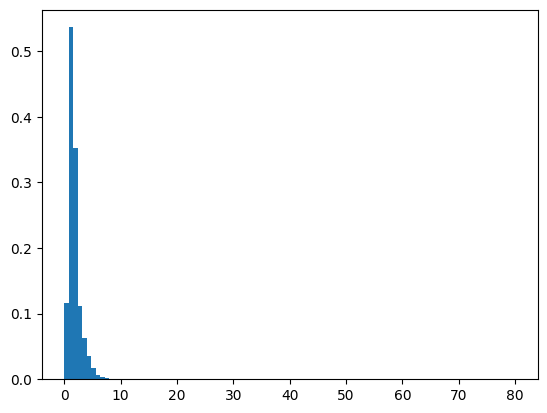

In [11]:
# Histograma de velocidad del viento
plt.hist(data['ValorObservado'], bins=100, density=True)

### 3.2. Análisis de componentes

In [12]:
# Creando columna de inicio de mes
data['Start_Month'] = data['FechaObservacion'].dt.to_period('M').dt.to_timestamp()

# Creando tabla de mes y promedio diario de velocidad del viento
monthly_avg = data.groupby('Start_Month')['ValorObservado'].mean().reset_index()

# Haciendo que el index sean las mismas fechas
monthly_avg.index = monthly_avg['Start_Month']

In [13]:
monthly_avg.head()

,Start_Month,ValorObservado
Start_Month,,
2012-06-01,2012-06-01,1.631328
2012-07-01,2012-07-01,1.552800
2012-08-01,2012-08-01,1.665927
2012-09-01,2012-09-01,1.595463
2012-10-01,2012-10-01,2.003546


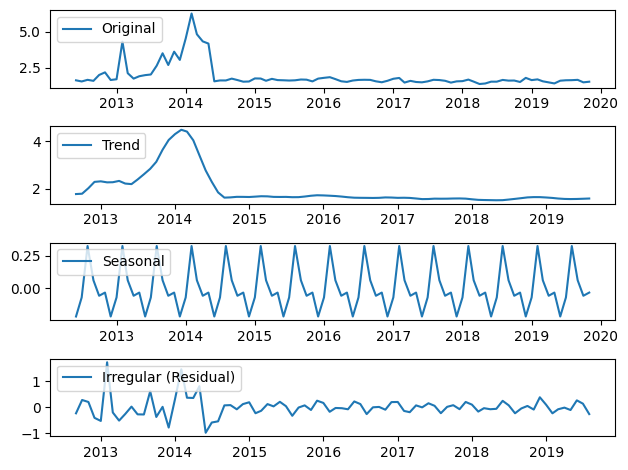

In [14]:
# Descomposición de la serie, descomposición aditiva por mes
decomposition = seasonal_decompose(monthly_avg['ValorObservado'], model='additive', period=6)

plt.figure()
plt.subplot(411)
plt.plot(monthly_avg['ValorObservado'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(decomposition.resid, label='Irregular (Residual)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 3.3. Detección de anomalías

Outliers detectados (Z-Score):
                       FechaObservacion  ValorObservado Start_Month    z_score
FechaObservacion                                                              
2012-08-26 17:10:00 2012-08-26 17:10:00            15.1  2012-08-01   4.659569
2012-08-26 17:30:00 2012-08-26 17:30:00            11.2  2012-08-01   3.280457
2012-08-26 17:40:00 2012-08-26 17:40:00            45.4  2012-08-01  15.374210
2012-08-26 17:50:00 2012-08-26 17:50:00            38.5  2012-08-01  12.934242
2012-08-26 18:00:00 2012-08-26 18:00:00            42.6  2012-08-01  14.384078
...                                 ...             ...         ...        ...
2014-05-09 10:50:00 2014-05-09 10:50:00            48.0  2014-05-01  16.293618
2014-05-09 11:00:00 2014-05-09 11:00:00            40.3  2014-05-01  13.570755
2014-05-09 11:10:00 2014-05-09 11:10:00            45.3  2014-05-01  15.338848
2014-05-09 15:10:00 2014-05-09 15:10:00            48.1  2014-05-01  16.328980
2014-05-09 15:20:00 2

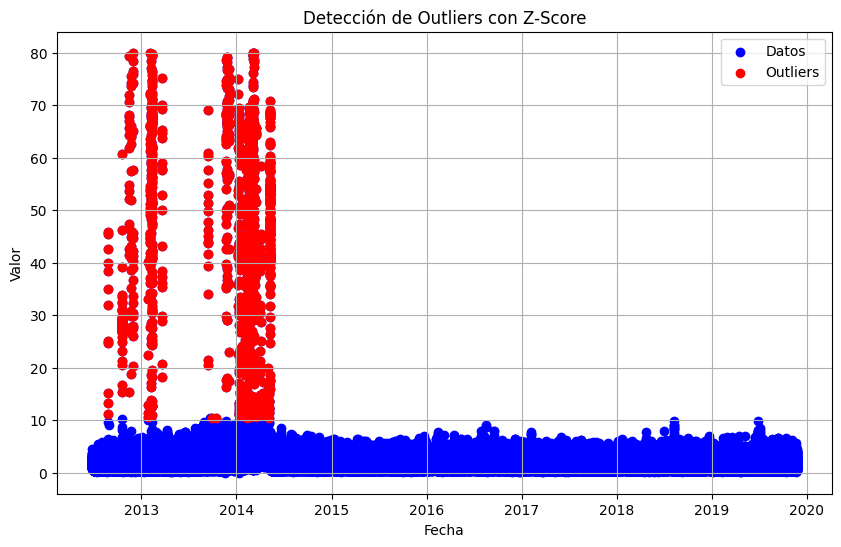

In [15]:
# Calcular Z-Score
data['z_score'] = zscore(data['ValorObservado'])

# Detectar outliers
outliers_z = data[data['z_score'].abs() > 3]
print("Outliers detectados (Z-Score):")
print(outliers_z)

# Graficar la serie con los outliers
plt.figure(figsize=(10, 6))
plt.scatter(data.index, data['ValorObservado'], label='Datos', color='blue')
plt.scatter(outliers_z.index, outliers_z['ValorObservado'], color='red', label='Outliers')
plt.title("Detección de Outliers con Z-Score")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

## 4. Estacionalidad y periodicidad

### 4.1. Análisis de patrones recurrentes

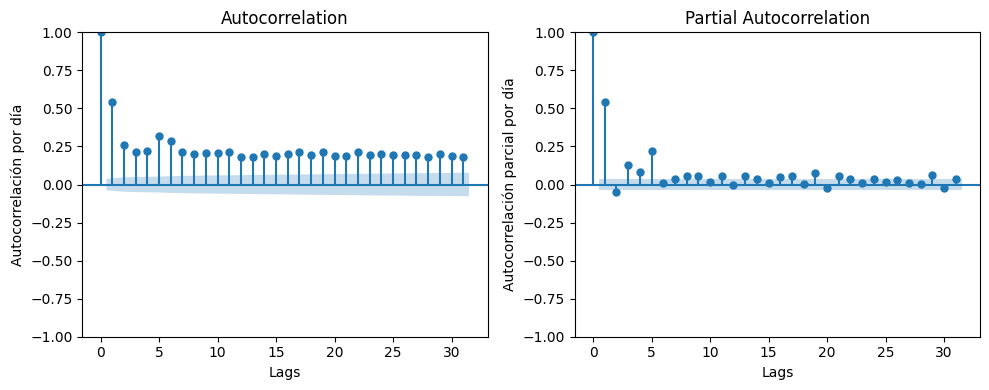

In [18]:
# Gráfica de autocorrelación y autocorrelación parcial de la serie

# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfica de autocorrelación
plot_acf(df_daily_avg['ValorObservado'], lags=31, ax=axes[0])
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("Autocorrelación por día")

# Gráfica de autocorrelación parcial
plot_pacf(df_daily_avg['ValorObservado'], lags=31, ax=axes[1])
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("Autocorrelación parcial por día")

plt.tight_layout()
plt.show()

In [19]:
# Creando columna de año
data['Year'] = data['FechaObservacion'].dt.year

Text(0, 0.5, 'velocidad del viento')

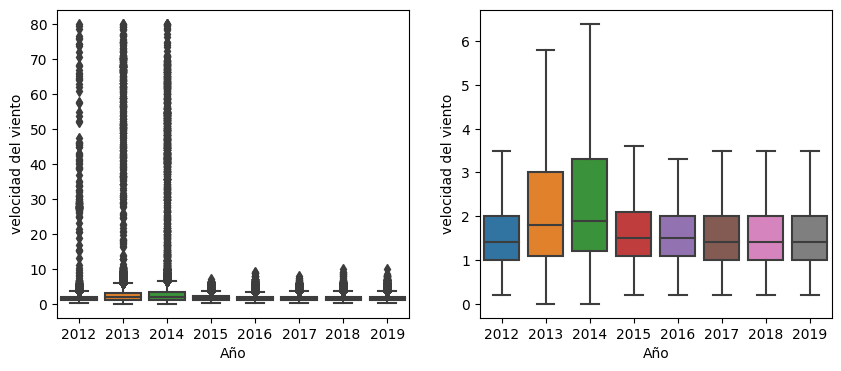

In [20]:
# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfica de caja y bigote
sns.boxplot(x=data['Year'], y=data['ValorObservado'],  ax=axes[0])
axes[0].set_xlabel("Año")
axes[0].set_ylabel("velocidad del viento")

# Gráfica de caja y bigote sin valores extremos
sns.boxplot(x=data['Year'], y=data['ValorObservado'], ax=axes[1], showfliers=False)
axes[1].set_xlabel("Año")
axes[1].set_ylabel("velocidad del viento")

In [21]:
# Obtengo los valores únicos de los años
years = data['Year'].unique() 

# Agrupo los datos por año
groups = [data[data['Year'] == year]['ValorObservado'] for year in years]

In [22]:
# Aplico prueba de Levene para la igualdad de varianzas
stats.levene(*groups)

LeveneResult(statistic=1444.361364314255, pvalue=0.0)

In [ ]:
# Aplico prueba de ANOVA de Welch, para ver si hay diferencias en las medias por año
pg.welch_anova(dv='ValorObservado', between='Year', data=data) 

,Source,ddof1,ddof2,F,p-unc,np2
0,Year,7,151658.302804,810.731335,0.0,0.031759


### 4.2. Transformación del dominio del tiempo

In [27]:
# Creando columna de inicio de semana
data['Start_Week'] = data['FechaObservacion'].dt.to_period('W').dt.to_timestamp()

# Creando tabla de semana y promedio semanal de velocidad del viento
weekly_avg = data.groupby('Start_Week')['ValorObservado'].mean().reset_index()

In [28]:
weekly_avg.head()

,Start_Week,ValorObservado
0,2012-06-25,1.595541
1,2012-07-02,1.481548
2,2012-07-09,1.438393
3,2012-07-16,1.819940
4,2012-07-23,1.548611


Text(0, 0.5, 'velocidad del viento por mes')

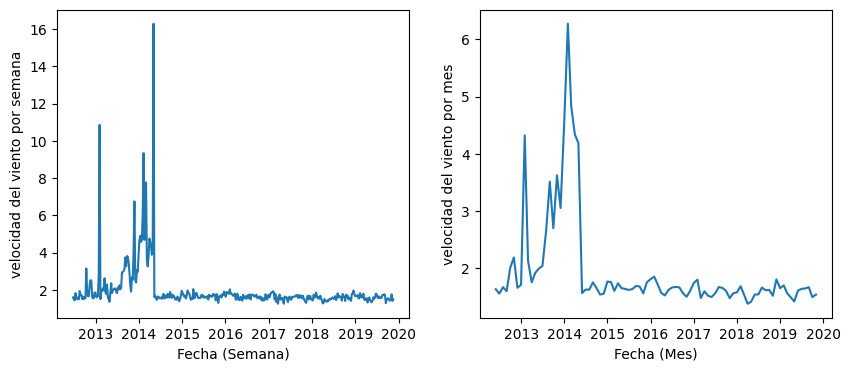

In [29]:
# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfica de velocidad del viento por semana
axes[0].plot(weekly_avg['Start_Week'], weekly_avg['ValorObservado'])
axes[0].set_xlabel("Fecha (Semana)")
axes[0].set_ylabel("velocidad del viento por semana")

# Gráfica de velocidad del viento por mes
axes[1].plot(monthly_avg['Start_Month'], monthly_avg['ValorObservado'])
axes[1].set_xlabel("Fecha (Mes)")
axes[1].set_ylabel("velocidad del viento por mes")

## 5. Análisis de tendencia

In [20]:
# Se define función de suavisazión
def firstsmooth(y, lambda_, start=None):
    ytilde = y.copy()
    if start is None:
        start = y[0]
    ytilde[0] = lambda_ * y[0] + (1 - lambda_) * start
    for i in range(1, len(y)):
        ytilde[i] = lambda_ * y[i] + (1 - lambda_) * ytilde[i - 1]
    return ytilde

In [21]:
# Se crea serie de los datos
data_ts = pd.Series(data=data['ValorObservado'].values, index = data['FechaObservacion'])

In [22]:
# Se aplica la función a la serie
data_smooth = firstsmooth(y=data_ts, lambda_=0.1)

C:\Users\luis_\AppData\Local\Temp\ipykernel_2152\4249688561.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  start = y[0]
C:\Users\luis_\AppData\Local\Temp\ipykernel_2152\4249688561.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ytilde[0] = lambda_ * y[0] + (1 - lambda_) * start
C:\Users\luis_\AppData\Local\Temp\ipykernel_2152\4249688561.py:6: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ytilde[0] = lambda_ * y[0] + (1

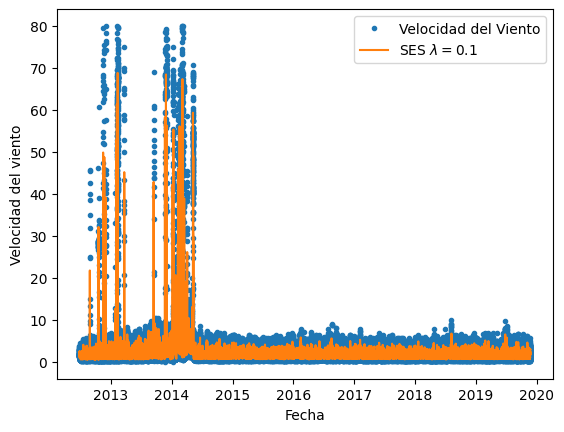

In [23]:
# Gráfica con datos suavizados
plt.plot(data_ts, marker='o', linestyle='', markersize=3, label='Velocidad del Viento')
plt.plot(data_smooth, label='SES $\lambda=0.1$')
plt.xlabel('Fecha')
plt.ylabel('Velocidad del viento')
plt.legend()
plt.show()

In [24]:
# Creo columna de media movil de 5 días
data['5-Day Moving Avg'] = data['ValorObservado'].rolling(720).mean()

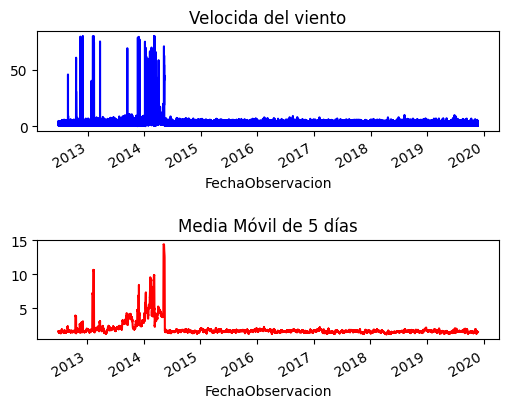

In [25]:
# Gráfica de medias moviles
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(2,1,1)
data['ValorObservado'].plot(ax=ax, color='b')
ax.set_title('Velocida del viento')
ax = fig.add_subplot(2,1,2)
data['5-Day Moving Avg'].plot(ax=ax, color='r')
ax.set_title('Media Móvil de 5 días')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)

## 6. Estabilidad de la serie

### 6.1. Análisis de estacionariedad

In [26]:
# Se realiza prueba de Kolmogorov-Smirnov para la normalidad
print('Kolmogorov-Smirnov:')
stat, p = stats.kstest(data['ValorObservado'], stats.norm.cdf)
print('Statistics=%.6f, p=%e' % (stat, p))

alpha = 0.05
if p > alpha:
 print('Sample looks Normal (fail to reject H0)')
else:
 print('Sample does not look Normal (reject H0)')

Kolmogorov-Smirnov:
Statistics=0.704191, p=0.000000e+00
Sample does not look Normal (reject H0)


In [27]:
# Prueba de Jarque-Bera para la normalidad
stats.jarque_bera(data['ValorObservado'])

SignificanceResult(statistic=1978477899.5949402, pvalue=0.0)

In [33]:
# Prueba de Dickey-Fuller aumentado (ADF)
adf_result = adfuller(data['ValorObservado'], autolag='AIC')

In [34]:
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -42.72456565149802
p-value: 0.0
Critical Values: {'1%': -3.4303670145201903, '5%': -2.8615475202126683, '10%': -2.566774002735368}


In [35]:
# Prueba de KPSS
kpss_result = kpss(data['ValorObservado'], regression='c', nlags="auto")

# Print the results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:", kpss_result[3])

KPSS Statistic: 10.925309544625428
p-value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\luis_\AppData\Local\Temp\ipykernel_12300\3818873849.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(data['ValorObservado'], regression='c', nlags="auto")


### 6.2. Transformaciones de datos

In [28]:
# Aplicando diferenciación
first_order_diff = data['ValorObservado'].diff(1)

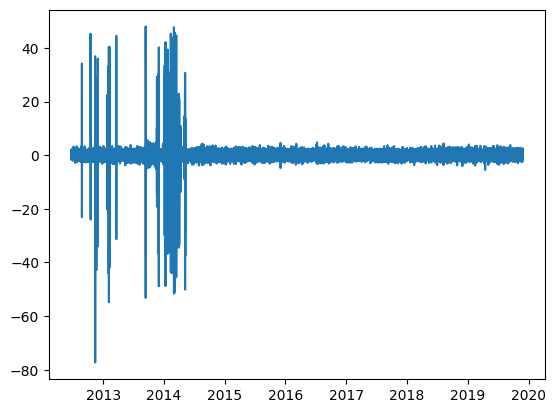

In [29]:
# Gráfica de la seria con datos diferenciados
plt.plot( first_order_diff.index, first_order_diff.values)

In [30]:
# Realizando prueba de ADF con los datos diferenciados

adf_result = adfuller(first_order_diff.iloc[1:], autolag='AIC')
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -97.23714881224768
p-value: 0.0
Critical Values: {'1%': -3.4303670145644602, '5%': -2.861547520232235, '10%': -2.566774002745783}


In [39]:
# Realizando prueba de KPSS con los datos diferenciados
kpss_result = kpss(first_order_diff.iloc[1:], regression='c', nlags="auto")

# Print the results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:", kpss_result[3])

KPSS Statistic: 0.0004464937388035633
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\luis_\AppData\Local\Temp\ipykernel_12300\403408010.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(first_order_diff.iloc[1:], regression='c', nlags="auto")


## 7. Análisis multivariado (no aplica)

En nuestro caso este paso no aplica ya que nosotros solo tenemos una variable a analizar, la velocidad del viento.

## 8. Identificación de ciclos y frecuencia

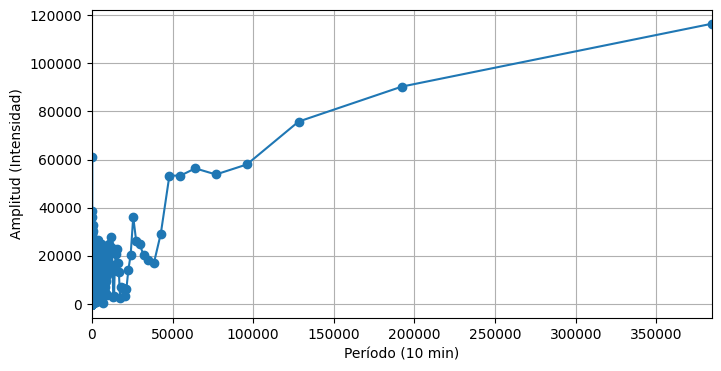

In [31]:
# Aplicamos la Transformada de Fourier
fft_values = fft(data['ValorObservado'].values)  # Coeficientes de Fourier
frequencies = fftfreq(384435)  # Frecuencias normalizadas

# Solo tomamos la mitad positiva (frecuencia positiva)
pos_mask = frequencies > 0
frequencies = frequencies[pos_mask]
fft_values = np.abs(fft_values[pos_mask])  # Magnitud de la FFT

# Graficamos el espectro de frecuencia
plt.figure(figsize=(8, 4))
plt.plot(1 / frequencies, fft_values, marker="o")  # Convertimos frecuencia en período (1/f)
plt.xlabel("Período (10 min)")
plt.ylabel("Amplitud (Intensidad)")
plt.xlim(0, 384435)  # Limitamos el eje x a ciclos relevantes
plt.grid()
plt.show()